# Recitation 0.3: Numpy Fundamentals

This notebook covers material for recitation 0.3 on numpy fundamentals. We will explore:
- Why do we need numpy?
- What is numpy and how do we import it?
- Basic array types: scalar, vector, matrix, tensor
- Indexing, slicing, and boolean masking
- Conditional slicing with np.where
- Axis-based operations: sum over columns/rows
- combining arrays via concatenation or stacking
- broadcasting
- elementwise, matrix and outer product

## Why Numpy?
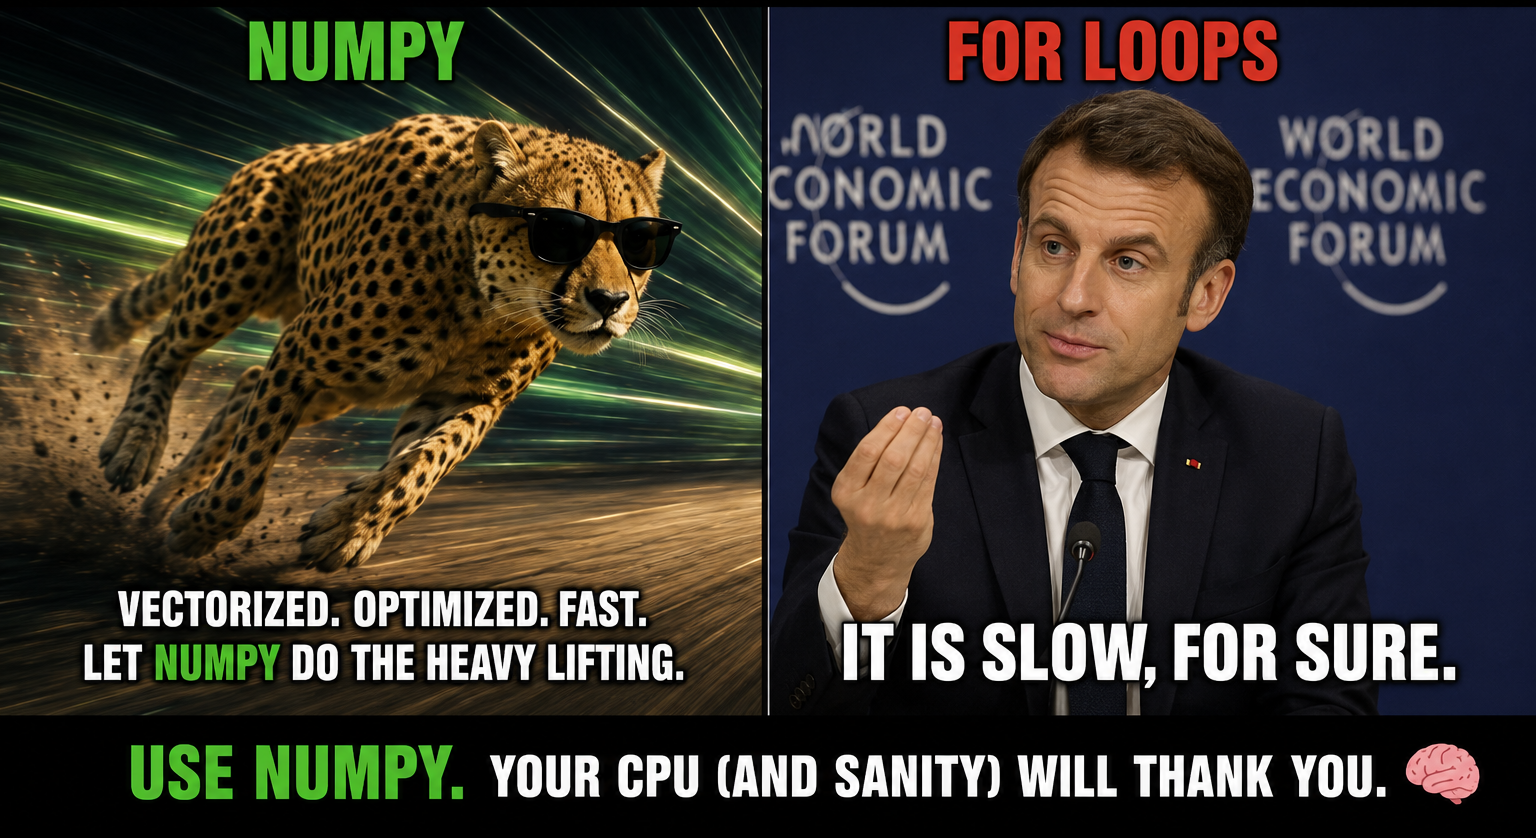

Consider the function
> matmul_python(List A, List B)

shown below. It attempts to do matrix multiplication between list A and list B using pure python.
Now, consider also the function

> matmul_numpy(List A, List B)

also shown below.





In [1]:
import numpy as np

def matmul_python(A, B):
    # Check if multiplication is possible
    if len(A[0]) != len(B):
        raise ValueError("Number of columns in A must equal number of rows in B")

    # Dimensions
    rows_A = len(A)
    cols_A = len(A[0])
    cols_B = len(B[0])

    # Initialize result matrix with zeros
    result = [[0 for _ in range(cols_B)] for _ in range(rows_A)]

    # Triple nested loop
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]

    return result

def matmul_numpy(A, B):
    A_np = np.array(A)
    B_np = np.array(B)

    return np.matmul(A_np, B_np)

Notice the simplicity that comes inherently with using numpy: an operation that takes nested loops and many lines of code can be simplified into fewer lines using numpy.
But elegance is not the only reason. Let us examine the performance.

In [2]:
# Defining test cases
import random

# Small (easy to verify by eye)
A_small = [
    [1, 2],
    [3, 4]
]

B_small = [
    [5, 6],
    [7, 8]
]

def generate_matrix(rows, cols):
    return [[random.randint(0, 10) for _ in range(cols)] for _ in range(rows)]

A_medium = generate_matrix(100, 100)
B_medium = generate_matrix(100, 100)

A_large = generate_matrix(300, 300)
B_large = generate_matrix(300, 300)

In [3]:
# Time tracking
import time

def time_function(func, A, B, name):
    start = time.time()
    func(A, B)
    end = time.time()
    print(f"{name}: {end - start:.4f} seconds")

In [4]:
# Running experiments
print("=== SMALL ===")
time_function(matmul_python, A_small, B_small, "Python")
time_function(matmul_numpy, A_small, B_small, "NumPy")

print("\n=== MEDIUM (100x100) ===")
time_function(matmul_python, A_medium, B_medium, "Python")
time_function(matmul_numpy, A_medium, B_medium, "NumPy")

print("\n=== LARGE (300x300) ===")
time_function(matmul_python, A_large, B_large, "Python")
time_function(matmul_numpy, A_large, B_large, "NumPy")

=== SMALL ===
Python: 0.0000 seconds
NumPy: 0.0001 seconds

=== MEDIUM (100x100) ===
Python: 0.0882 seconds
NumPy: 0.0022 seconds

=== LARGE (300x300) ===
Python: 2.5792 seconds
NumPy: 0.0370 seconds


As you can see above, using numpy is extremely faster than using regular python loops. Therefore, with numpy, you have both elegant code and faster runtimes.

## What is Numpy and How do we import it?

Numpy is a python library optimized to do numerical and scientific computation on large multi-dimensional arrays and tensors.

### Importing numpy
Importing numpy is as straightforward as below:


> import numpy as np

Often, the import is aliased as np. It is a good idea to print the version of numpy you are using.



In [5]:
import numpy as np
print(f"Numpy version: {np.__version__}")

Numpy version: 2.0.2


### Creating Numpy Arrays

Numpy can support arrays of any dimension through its core object: np.ndarray.
Below is a list of some of the ways to create a numpy array.

In [6]:
# Helper function to print shape and number of unique elements
def describe_array(arr, name):
    print(f"{name}:")
    print(arr)
    print("Shape:", arr.shape)
    print("Data type:", arr.dtype)
    print("Unique items:", len(np.unique(arr)))
    print("-" * 40)


# 1. From a Python list (1D array)
arr1 = np.array([1, 2, 3, 4, 5])
describe_array(arr1, "1D array from list")

1D array from list:
[1 2 3 4 5]
Shape: (5,)
Data type: int64
Unique items: 5
----------------------------------------


#### From a list

In [7]:
# 2. From a list of lists (2D array / matrix)
arr2 = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
describe_array(arr2, "2D array from list of lists")

2D array from list of lists:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


#### Array of 0s and 1s

In [9]:
# 3. Creating an array of zeros
arr3 = np.zeros((2, 3, 5))  # 2 rows, 3 columns
describe_array(arr3, "Zeros array (2x3)")

# 4. Creating an array of ones
arr4 = np.ones((3, 2))
describe_array(arr4, "Ones array (3x2)")

Zeros array (2x3):
[[[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]]
Shape: (2, 3, 5)
Data type: float64
Unique items: 1
----------------------------------------
Ones array (3x2):
[[1. 1.]
 [1. 1.]
 [1. 1.]]
Shape: (3, 2)
Data type: float64
Unique items: 1
----------------------------------------


#### Constant value array

In [11]:
# 5. Creating an array with a constant value
arr5 = np.full((2, 6), 7)
describe_array(arr5, "Constant array (all 7s)")

Constant array (all 7s):
[[7 7 7 7 7 7]
 [7 7 7 7 7 7]]
Shape: (2, 6)
Data type: int64
Unique items: 1
----------------------------------------


#### Array in range

In [13]:
# 6. Using arange (like Python range, but returns array)
arr6 = np.arange(0, 10, 2)  # start, stop, step
describe_array(arr6, "arange (0 to 10 step 2)")


# 7. Using linspace (evenly spaced values)
arr7 = np.linspace(0, 1, 5)  # 5 points between 0 and 1
describe_array(arr7, "linspace (0 to 1, 5 points)")

arange (0 to 10 step 2):
[0 2 4 6 8]
Shape: (5,)
Data type: int64
Unique items: 5
----------------------------------------
linspace (0 to 1, 5 points):
[0.   0.25 0.5  0.75 1.  ]
Shape: (5,)
Data type: float64
Unique items: 5
----------------------------------------


#### Identity Matrix

In [14]:
# 8. Identity matrix
arr8 = np.eye(3)  # 3x3 identity matrix
describe_array(arr8, "Identity matrix (3x3)")


Identity matrix (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Shape: (3, 3)
Data type: float64
Unique items: 2
----------------------------------------


#### Random Array

In [15]:

# 9. Random array (uniform distribution)
arr9 = np.random.rand(2, 3)  # values between 0 and 1
describe_array(arr9, "Random uniform array (2x3)")


# 10. Random integers
arr10 = np.random.randint(0, 10, size=(3, 3))
describe_array(arr10, "Random integer array (3x3)")

Random uniform array (2x3):
[[0.03043957 0.4247025  0.48943644]
 [0.30737599 0.49421009 0.52562451]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------
Random integer array (3x3):
[[7 6 8]
 [5 0 0]
 [0 6 0]]
Shape: (3, 3)
Data type: int64
Unique items: 5
----------------------------------------


#### Array of 0s/1s with Shape Similar to another Array

In [16]:

# 11. zeros_like (same shape as another array)
arr11 = np.zeros_like(arr2)
describe_array(arr11, "Zeros like arr2")


# 12. ones_like (same shape as another array)
arr12 = np.ones_like(arr2)
describe_array(arr12, "Ones like arr2")

Zeros like arr2:
[[0 0 0]
 [0 0 0]]
Shape: (2, 3)
Data type: int64
Unique items: 1
----------------------------------------
Ones like arr2:
[[1 1 1]
 [1 1 1]]
Shape: (2, 3)
Data type: int64
Unique items: 1
----------------------------------------


### Basic data types

Notice that in the examples above, all elements in the array are initialized to a 64-bit data type (np.float64 or np.int64). However, there are other data types like


```
np.bool, np.int8, np.uint8, np.complex
```
The full list of available numpy classes can be found here: https://numpy.org/doc/stable/user/basics.types.html

At initialization time, any method you use allows you to specify the data type of the array through the dtype parameter or casting it with the astype method.

**Important**: Numpy arrays only contains items of the same datatype. When creating from a list, all list elements must be of the same type


In [17]:
# Default dtype
arr9 = np.random.rand(2, 3)  # values between 0 and 1
describe_array(arr9, "Random uniform array (2x3)")

# 7. Using linspace (evenly spaced values)
arr7 = np.linspace(0, 10, 5)  # 5 points between 0 and 1
describe_array(arr7, "linspace (0 to 10, 5 points)")

print('--------------------')
# 9. Random array (uniform distribution)
arr9 = np.random.rand(2, 3).astype(np.float16)  # values between 0 and 1
describe_array(arr9, "Random uniform array (2x3)")

# 7. Using linspace (evenly spaced values)
arr7 = np.linspace(0, 10, 5, dtype=np.uint8)  # 5 points between 0 and 1
describe_array(arr7, "linspace (0 to 10, 5 points)")


Random uniform array (2x3):
[[0.93973979 0.26817787 0.57451384]
 [0.64512575 0.3874263  0.96905015]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------
linspace (0 to 10, 5 points):
[ 0.   2.5  5.   7.5 10. ]
Shape: (5,)
Data type: float64
Unique items: 5
----------------------------------------
--------------------
Random uniform array (2x3):
[[0.3413 0.763  0.373 ]
 [0.8325 0.951  0.2756]]
Shape: (2, 3)
Data type: float16
Unique items: 6
----------------------------------------
linspace (0 to 10, 5 points):
[ 0  2  5  7 10]
Shape: (5,)
Data type: uint8
Unique items: 5
----------------------------------------


## Elementwise operations

In [23]:
# Assume two arrays with same shape
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

B = np.array([
    [10, 20, 30],
    [40, 50, 0]
])

describe_array(A, "Array A")
describe_array(B, "Array B")

Array A:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------
Array B:
[[10 20 30]
 [40 50  0]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [19]:
# Addition
describe_array(A + B, "A + B")

A + B:
[[11 22 33]
 [44 55 66]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [20]:
# Elementwise subtraction
describe_array(A - B, "A - B")

A - B:
[[ -9 -18 -27]
 [-36 -45 -54]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [21]:
# Elementwise multiplication
describe_array(A * B, "A * B")

A * B:
[[ 10  40  90]
 [160 250 360]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [26]:
# Elementwise division
describe_array(A / (B+1e-8), "A / B")

A / B:
[[9.99999999e-02 1.00000000e-01 1.00000000e-01]
 [1.00000000e-01 1.00000000e-01 6.00000000e+08]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------


In [27]:
# Scalar operations
describe_array(A + 10, "A + 10")
describe_array(A - 10, "A - 10")
describe_array(A * 10, "A * 10")

A + 10:
[[11 12 13]
 [14 15 16]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------
A - 10:
[[-9 -8 -7]
 [-6 -5 -4]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------
A * 10:
[[10 20 30]
 [40 50 60]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [28]:
# Exponentiation
describe_array(A ** 2, "A ** 2")

A ** 2:
[[ 1  4  9]
 [16 25 36]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [29]:
# Common mathematical operations
describe_array(np.sin(A), "sin(A)")
describe_array(np.cos(A), "cos(A)")
describe_array(np.exp(A), "exp(A)")
describe_array(np.log(A), "log(A)")
describe_array(np.sqrt(A), "sqrt(A)")

sin(A):
[[ 0.84147098  0.90929743  0.14112001]
 [-0.7568025  -0.95892427 -0.2794155 ]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------
cos(A):
[[ 0.54030231 -0.41614684 -0.9899925 ]
 [-0.65364362  0.28366219  0.96017029]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------
exp(A):
[[  2.71828183   7.3890561   20.08553692]
 [ 54.59815003 148.4131591  403.42879349]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------
log(A):
[[0.         0.69314718 1.09861229]
 [1.38629436 1.60943791 1.79175947]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------
sqrt(A):
[[1.         1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]]
Shape: (2, 3)
Data type: float64
Unique items: 6
----------------------------------------


In [30]:
# Comparisons
describe_array(A > B, "A > B")

A > B:
[[False False False]
 [False False  True]]
Shape: (2, 3)
Data type: bool
Unique items: 2
----------------------------------------


## Indexing, Slicing and Boolean Masking

Numpy allows us O(1) access to elements by indexing.
Consider the array A below. It is a 2-D array. We can access an element by refering the row, then the column it lies on.

In [31]:
A = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

describe_array(A, "Array A")

Array A:
[[10 20 30]
 [40 50 60]
 [70 80 90]]
Shape: (3, 3)
Data type: int64
Unique items: 9
----------------------------------------


In [33]:
print("Element at row 0, col 1:", A[0, 1])
print("Element at row 2, col 2:", A[2, 2])

Element at row 0, col 1: 20
Element at row 2, col 2: 90


We also have the luxury of using negative indices, for which -1 stands for the last item in the array in a particular dimension.

In [35]:
print("Last element:", A[-1, -1])
print("Last row:", A[:, -1])

Last element: 90
Last row: [30 60 90]


### Slicing

Slicing allows us to work with only a subsection of the array. It normally takes the form:


```
A[start:stop:step,..., start:stop]
```
where dimensions are comma separated.
Unlike in normal python, slicing does not create a copy. Changing any value in a slice therefore affects the original array.


In [36]:
rows = A[0:2, :]   # first 2 rows
describe_array(rows, "First two rows")

First two rows:
[[10 20 30]
 [40 50 60]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [37]:
cols = A[:, 1:3]   # columns 1 and 2
describe_array(cols, "Last two columns")

Last two columns:
[[20 30]
 [50 60]
 [80 90]]
Shape: (3, 2)
Data type: int64
Unique items: 6
----------------------------------------


In [38]:
step = A[:, ::2]  # every 2nd column
describe_array(step, "Every second column")

Every second column:
[[10 30]
 [40 60]
 [70 90]]
Shape: (3, 2)
Data type: int64
Unique items: 6
----------------------------------------


In [39]:
B = A.copy() # B = A[:]

B[0, 0] = 999
describe_array(B, "Modified B (changed one value)")

Modified B (changed one value):
[[999  20  30]
 [ 40  50  60]
 [ 70  80  90]]
Shape: (3, 3)
Data type: int64
Unique items: 9
----------------------------------------


In [40]:
B[1, :] = 0
describe_array(B, "Row 1 set to zeros")

Row 1 set to zeros:
[[999  20  30]
 [  0   0   0]
 [ 70  80  90]]
Shape: (3, 3)
Data type: int64
Unique items: 7
----------------------------------------


In [41]:
B[:, 2] = -1
describe_array(B, "Last column set to -1")

Last column set to -1:
[[999  20  -1]
 [  0   0  -1]
 [ 70  80  -1]]
Shape: (3, 3)
Data type: int64
Unique items: 6
----------------------------------------


### Boolean masking

Numpy allows us to specify a list of elements that satisfies a particular condition. The condition is expressed as an array of booleans where indices with value 1 or True in the mask are selected from the main array.

Consider the example below. mask is a boolean array that has True if the element in A is > 50 and False otherwise

In [42]:
mask = A > 50
describe_array(mask, "Mask (A > 50)")

Mask (A > 50):
[[False False False]
 [False False  True]
 [ True  True  True]]
Shape: (3, 3)
Data type: bool
Unique items: 2
----------------------------------------


We can therefore use the mask to select only items > 50.

In [43]:
filtered = A[mask]
describe_array(filtered, "Values greater than 50")

Values greater than 50:
[60 70 80 90]
Shape: (4,)
Data type: int64
Unique items: 4
----------------------------------------


We can also create composite conditions with logical operations. Below for example. we find elements > 20 and < 80.

In [45]:
mask = (A > 20) & (A < 80)
filtered = A[mask]
describe_array(filtered, "Values between 20 and 80")

Values between 20 and 80:
[30 40 50 60 70]
Shape: (5,)
Data type: int64
Unique items: 5
----------------------------------------


We can also specify exactly which items to retrieve.

In [46]:
rows = [0, 2]
cols = [1, 2]

selected = A[rows, cols]
describe_array(selected, "Selected elements (0,1) and (2,2)")

Selected elements (0,1) and (2,2):
[20 90]
Shape: (2,)
Data type: int64
Unique items: 2
----------------------------------------


## Broadcasting

Broadcasting allows Numpy to perform operations on arrays of different shapes without copying the data.
Let us revisit an example we saw above: adding a scalar to an array.

In [49]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

describe_array(A, "Array A")

B = A + 10
describe_array(B, "A + 10")

Array A:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------
A + 10:
[[11 12 13]
 [14 15 16]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


Internally, numpy treats the array as [[10, 10, 10],
 [10, 10, 10]] without actually creating it.
 Broadcasting follow two rules:
 - Two dimensions must be equal
 - One of the two dimensions must be 1

In [50]:
# This works
row = np.array([10, 20, 30])
describe_array(row, "Row vector")

C = A + row
describe_array(C, "A + row")

Row vector:
[10 20 30]
Shape: (3,)
Data type: int64
Unique items: 3
----------------------------------------
A + row:
[[11 22 33]
 [14 25 36]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [53]:
# This fails
bad = np.array([100, 200])  # shape (2,)

A + bad

ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

In [57]:
# You can reshape the shape if possible to make broadcasting possible
col_fixed = np.array([100, 200]).reshape(2, 1)
describe_array(col_fixed, "Fixed column vector")

E = A + col_fixed
describe_array(E, "A + fixed column")

Fixed column vector:
[[100]
 [200]]
Shape: (2, 1)
Data type: int64
Unique items: 2
----------------------------------------
A + fixed column:
[[101 102 103]
 [204 205 206]]
Shape: (2, 3)
Data type: int64
Unique items: 6
----------------------------------------


In [58]:
# Knowledge of this helps you in normalization
mean = np.array([2.5, 3.5, 4.5])
G = A - mean
describe_array(G, "A - column means")

A - column means:
[[-1.5 -1.5 -1.5]
 [ 1.5  1.5  1.5]]
Shape: (2, 3)
Data type: float64
Unique items: 2
----------------------------------------


### Conditional Slicing with np.where

In [60]:
A = np.array([
    [10, 25, 30],
    [45, 50, 60],
    [70, 80, 90]
])
indices = np.where(A > 50)
print("Indices where A > 50:", indices)

Indices where A > 50: (array([1, 2, 2, 2]), array([2, 0, 1, 2]))


The output is a tuple of arrays showing the row index and column index of elements where the condition is True. We can then use the indices to extract values.

In [61]:
values = A[indices]
describe_array(values, "Values where A > 50")

Values where A > 50:
[60 70 80 90]
Shape: (4,)
Data type: int64
Unique items: 4
----------------------------------------


In [62]:
# We can apply more control
B = np.where(A > 50, 1, 0)
describe_array(B, "1 where A > 50, else 0")

1 where A > 50, else 0:
[[0 0 0]
 [0 0 1]
 [1 1 1]]
Shape: (3, 3)
Data type: int64
Unique items: 2
----------------------------------------


In [63]:
# Replacing values conditionally
C = np.where(A > 50, A, 0)
describe_array(C, "Keep values > 50, else 0")

Keep values > 50, else 0:
[[ 0  0  0]
 [ 0  0 60]
 [70 80 90]]
Shape: (3, 3)
Data type: int64
Unique items: 5
----------------------------------------


In [64]:
# We can combine conditions
F = np.where((A > 20) & (A < 80), A, -1)
describe_array(F, "Keep values between 20 and 80, else -1")

Keep values between 20 and 80, else -1:
[[-1 25 30]
 [45 50 60]
 [70 -1 -1]]
Shape: (3, 3)
Data type: int64
Unique items: 7
----------------------------------------


In [65]:
# Or form nested conditions
G = np.where(
    A < 30, 0,
    np.where(A < 70, 1, 2)
)

describe_array(G, "Categorize values into 3 groups")

Categorize values into 3 groups:
[[0 0 1]
 [1 1 1]
 [2 2 2]]
Shape: (3, 3)
Data type: int64
Unique items: 3
----------------------------------------


## Aggregations

In [66]:
A = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

describe_array(A, "Array A")

print("Sum:", np.sum(A))
print("Mean:", np.mean(A))
print("Min:", np.min(A))
print("Max:", np.max(A))

Array A:
[[10 20 30]
 [40 50 60]
 [70 80 90]]
Shape: (3, 3)
Data type: int64
Unique items: 9
----------------------------------------
Sum: 450
Mean: 50.0
Min: 10
Max: 90


In [67]:
# We can apply the operation columnwise
col_sum = np.sum(A, axis=0)
describe_array(col_sum, "Column sums")

Column sums:
[120 150 180]
Shape: (3,)
Data type: int64
Unique items: 3
----------------------------------------


In [68]:
# Or row-wise
row_sum = np.sum(A, axis=1)
describe_array(row_sum, "Row sums")

Row sums:
[ 60 150 240]
Shape: (3,)
Data type: int64
Unique items: 3
----------------------------------------


In [69]:
# We might want to keep the dimenssions after the operation for further broadcasting
row_sum = np.sum(A, axis=1, keepdims=True)
describe_array(row_sum, "Row sums")

Row sums:
[[ 60]
 [150]
 [240]]
Shape: (3, 1)
Data type: int64
Unique items: 3
----------------------------------------


In [70]:
# We can do conditional aggregation
mask = A > 50
filtered_mean = np.mean(A[mask])

print("Mean of values > 50:", filtered_mean)

Mean of values > 50: 75.0


In [71]:
# We can get indices with argmax and argmin. If no axis specified, the array will be flattened first
print("Index of max value:", np.argmax(A))
print("Index of min value:", np.argmin(A))

Index of max value: 8
Index of min value: 0


In [72]:
# We can specify the dimension along which we want the index of minimum or maximum
describe_array(np.argmax(A, axis=0), "Index of max in each column")
describe_array(np.argmax(A, axis=1), "Index of max in each row")

Index of max in each column:
[2 2 2]
Shape: (3,)
Data type: int64
Unique items: 1
----------------------------------------
Index of max in each row:
[2 2 2]
Shape: (3,)
Data type: int64
Unique items: 1
----------------------------------------


Note: It is common to confuse axis to which you want to compute the operation.
Rule of thumb is that axis = the dimension you want to collapse.
- 0 collapses rows to (1 x ncols)
- 1 collapses columns to (nrows x 1)

## Combining Arrays

We can combine arrays (stack/concatenate) and change their shape (reshape) without changing the data itself.
Shapes must match except along the axis you are concatenating

### Concatenating

In [73]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

describe_array(A, "Array A")
describe_array(B, "Array B")

Array A:
[[1 2]
 [3 4]]
Shape: (2, 2)
Data type: int64
Unique items: 4
----------------------------------------
Array B:
[[5 6]
 [7 8]]
Shape: (2, 2)
Data type: int64
Unique items: 4
----------------------------------------


In [74]:
# Concatenating along rows
C = np.concatenate([A, B], axis=0)
describe_array(C, "Concatenate along rows (axis=0)")

Concatenate along rows (axis=0):
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Shape: (4, 2)
Data type: int64
Unique items: 8
----------------------------------------


In [75]:
# concatenating along columns
D = np.concatenate([A, B], axis=1)
describe_array(D, "Concatenate along columns (axis=1)")

Concatenate along columns (axis=1):
[[1 2 5 6]
 [3 4 7 8]]
Shape: (2, 4)
Data type: int64
Unique items: 8
----------------------------------------


### Stacking
Stacking puts one array after the other and creates a new dimension

In [ ]:
E = np.stack([A, B], axis=0)
describe_array(E, "Stack along new axis=0")

Stack along new axis=0:
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
Shape: (2, 2, 2)
Data type: int64
Unique items: 8
----------------------------------------


In [76]:
# You can also stack along an axis
F = np.stack([A, B], axis=1)
describe_array(F, "Stack along new axis=1")

Stack along new axis=1:
[[[1 2]
  [5 6]]

 [[3 4]
  [7 8]]]
Shape: (2, 2, 2)
Data type: int64
Unique items: 8
----------------------------------------


In [77]:
# There are shortcuts for vertical and horizontal stacking
G = np.vstack([A, B])
describe_array(G, "Vertical stack")

H = np.hstack([A, B])
describe_array(H, "Horizontal stack")

Vertical stack:
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Shape: (4, 2)
Data type: int64
Unique items: 8
----------------------------------------
Horizontal stack:
[[1 2 5 6]
 [3 4 7 8]]
Shape: (2, 4)
Data type: int64
Unique items: 8
----------------------------------------


### Reshaping

Reshaping changes the structure of the arrays without changing the elements themselves.

In [78]:
X = np.arange(12)
describe_array(X, "Original 1D array")

Original 1D array:
[ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)
Data type: int64
Unique items: 12
----------------------------------------


In [81]:
Y = X.reshape(3, 4)
describe_array(Y, "Reshaped to (3,4)")

Reshaped to (3,4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)
Data type: int64
Unique items: 12
----------------------------------------


In [82]:
Z = X.reshape(2, 6)
describe_array(Z, "Reshaped to (2,6)")

Reshaped to (2,6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
Shape: (2, 6)
Data type: int64
Unique items: 12
----------------------------------------


In [84]:
W = X.reshape(3, -1)
describe_array(W, "Reshape with -1")

Reshape with -1:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)
Data type: int64
Unique items: 12
----------------------------------------


In [85]:
# Flattening arrays
flat = Y.flatten()
describe_array(flat, "Flattened array")

Flattened array:
[ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)
Data type: int64
Unique items: 12
----------------------------------------


## All things multiplications

So far, we have seen elementwise multiplication between two arrays where one array element multiplies a similarly indexed element in the other array. Consider the two arrays below.

In [86]:
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

C = A * B
describe_array(C, "Elementwise multiplication (A * B)")

Elementwise multiplication (A * B):
[[ 5 12]
 [21 32]]
Shape: (2, 2)
Data type: int64
Unique items: 4
----------------------------------------


Matrix multiplication allows us to create a composite matrix that is equivalent to applying the matrices sequentially on a vector. There are two ways to do matrix multiplication between arrays A and B:

```
 way_1 = A @ B
 way_2 = np.matmul(A, B)
```
Both ways work well.


In [88]:
D = B @ A
describe_array(D, "Matrix multiplication (A @ B)")
E = np.matmul(A, B)
describe_array(E, "Matrix multiplication (np.matmul(A, B))")

Matrix multiplication (A @ B):
[[23 34]
 [31 46]]
Shape: (2, 2)
Data type: int64
Unique items: 4
----------------------------------------
Matrix multiplication (np.matmul(A, B)):
[[19 22]
 [43 50]]
Shape: (2, 2)
Data type: int64
Unique items: 4
----------------------------------------


An outer product is defined on two vectors. Take two vectors u and v for instance. An outer product will be a matrix formed by multiplying every element of u by every element of v.

In [89]:
x = np.array([1, 2, 3])
y = np.array([4, 5])

describe_array(x, "Vector x")
describe_array(y, "Vector y")

outer = np.outer(x, y)
describe_array(outer, "Outer product")

Vector x:
[1 2 3]
Shape: (3,)
Data type: int64
Unique items: 3
----------------------------------------
Vector y:
[4 5]
Shape: (2,)
Data type: int64
Unique items: 2
----------------------------------------
Outer product:
[[ 4  5]
 [ 8 10]
 [12 15]]
Shape: (3, 2)
Data type: int64
Unique items: 6
----------------------------------------


A dot product is a product between two vectors and produce a scalar. Given two vectors u and v, the dot product is mathematically obtained by:

u.v = \(|u| x |v| x cos(theta)\)

Where theta is the angle between them and |u| us the magnitude of vector u.
Since the product depend on the angle between them, you can see the product will be 0 if u and v are orthogonal. Notice that it is also maximum when theta is zero.
Thus, one of the use case for dot procucts is assessing similarity between two vectoes.


In [90]:
dot = np.dot(x, np.array([4, 5, 6]))
print("Dot product:", dot)

Dot product: 32
